In [18]:
#Section 1: Exploratory Data Analysis (EDA)

import pandas as pd
import numpy as np

# Load the training dataset
dataset = pd.read_csv('people.csv')
data = pd.read_csv('people.csv')

# 1. Check Shape
print("Dataset Shape:", dataset.shape)


Dataset Shape: (14999, 10)


In [4]:
display(dataset.head(10))


,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
5,0.10,0.77,6,247,4,0,1,0,sales,low
6,0.92,0.85,5,259,5,0,1,0,sales,low
7,0.42,0.53,2,142,3,0,1,0,sales,low
8,0.45,0.54,2,135,3,0,1,0,sales,low
9,0.11,0.81,6,305,4,0,1,0,sales,low


In [5]:
print(dataset.duplicated().sum())


3008


In [6]:
dataset[dataset.duplicated()] 
dataset.drop_duplicates(inplace=True) 

In [7]:
print(dataset.duplicated().sum())

0


In [ ]:
import  seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(dataset.isnull())
plt.show()

In [8]:
dataset.isnull().sum()  # There is no Missing Value in Dataset

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [9]:
display(dataset.describe(include='all'))

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991,11991
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3239,5740
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,NaN,NaN
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [10]:
salary_map = {
    'low': 1,
    'medium': 2,
    'high': 3
}

dataset['salary_num'] = dataset['salary'].map(salary_map)

In [11]:
avg_salary = dataset.groupby('dept')['salary_num'].mean()

highest = avg_salary.idxmax()
lowest = avg_salary.idxmin()

print("Highest Average Salary Department:")
print(highest, avg_salary.max())

print("\nLowest Average Salary Department:")
print(lowest, avg_salary.min())

Highest Average Salary Department:
management 1.974770642201835

Lowest Average Salary Department:
technical 1.5668449197860963


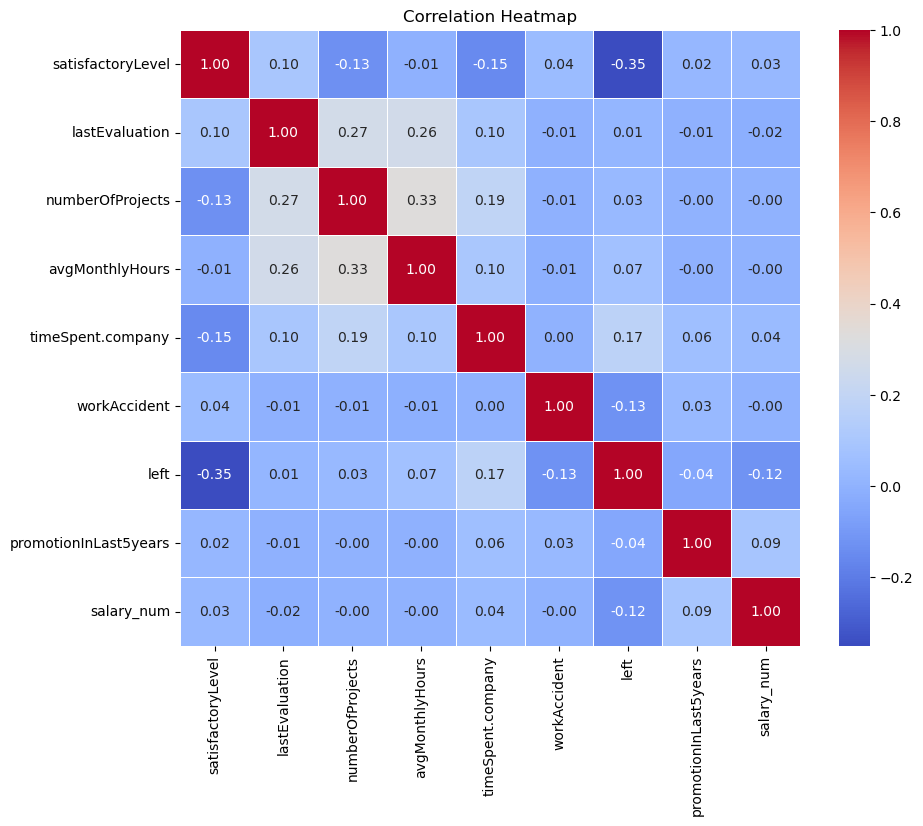

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_data = dataset.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

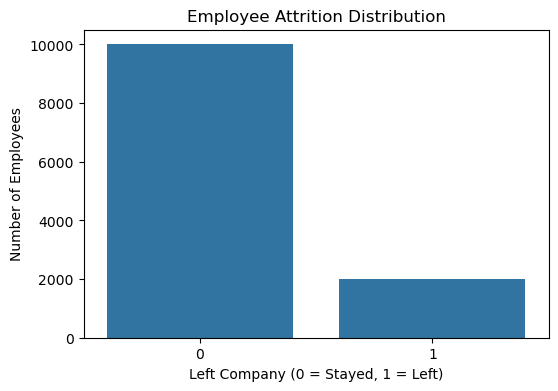

In [14]:
#distribution of employees who left vs. those who stayed.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='left', data=dataset)

plt.title("Employee Attrition Distribution")
plt.xlabel("Left Company (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")

plt.show()

In [15]:
# Calculate attrition rate by department
attrition_rate = dataset.groupby('dept')['left'].mean().sort_values(ascending=False) * 100

print(attrition_rate)

dept
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: left, dtype: float64


In [20]:
print(dataset['salary'].unique())
print(dataset['dept'].unique())


['low' 'medium' 'high']
['sales' 'accounting' 'hr' 'technical' 'support' 'IT' 'product_mng'
 'marketing' 'management' 'RandD']


In [21]:
#Section 2: Feature Engineering & Preprocessing
#Encoding the coloumns salary,department
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Columns to encode
cat_cols = ['salary', 'dept']

# One-Hot Encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded = ohe.fit_transform(dataset[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=dataset.index
)

# Drop original columns and add encoded columns
dataset = pd.concat([dataset.drop(columns=cat_cols), encoded_df], axis=1)

In [22]:
dataset.head(5)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,salary_low,salary_medium,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.80,0.86,5,262,6,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.11,0.88,7,272,4,0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.37,0.52,2,159,3,0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.41,0.50,2,153,3,0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [69]:
(dataset.isnull().sum()/dataset.shape[0])*100

CustomerID           0.000227
Age                  0.000227
Gender               0.000227
Tenure               0.000227
Usage Frequency      0.000227
Support Calls        0.000227
Payment Delay        0.000227
Subscription Type    0.000227
Contract Length      0.000227
Total Spend          0.000227
Last Interaction     0.000227
Churn                0.000227
dtype: float64

In [23]:
from sklearn.preprocessing import MinMaxScaler

# Select all numerical columns except Churn
num_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.drop('left')

# Initialize scaler
scaler = MinMaxScaler()

# Scale and save back to the original dataset
dataset[num_cols] = scaler.fit_transform(dataset[num_cols])

In [24]:
dataset.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,salary_low,salary_medium,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.307692,0.250000,0.0,0.294393,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.351648,0.218750,0.0,0.266355,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [25]:
#split  train (75%) and test (25%)

from sklearn.model_selection import train_test_split

# Features and target
X = dataset.drop(columns=['left'])
y = dataset['left']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (11249, 18)
Testing set shape: (3750, 18)


In [29]:
#Section 3: Machine Learning Model
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression(random_state=42)

# Train model
lr_model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
# Predict on test data
y_pred = lr_model.predict(X_test)

In [31]:
#Model Evalution

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

Confusion Matrix:
[[2634  223]
 [ 579  314]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      2857
           1       0.58      0.35      0.44       893

    accuracy                           0.79      3750
   macro avg       0.70      0.64      0.65      3750
weighted avg       0.76      0.79      0.77      3750


Accuracy: 0.7861333333333334


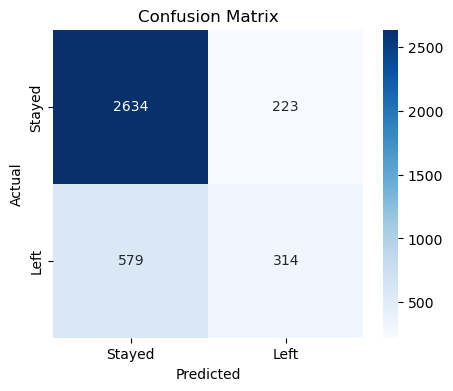

In [32]:
#Visualise Confusion Matrix 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [33]:
#Section 4: Relationship & Visualization (Insights)
dataset.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,salary_low,salary_medium,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.307692,0.250000,0.0,0.294393,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.351648,0.218750,0.0,0.266355,0.125,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


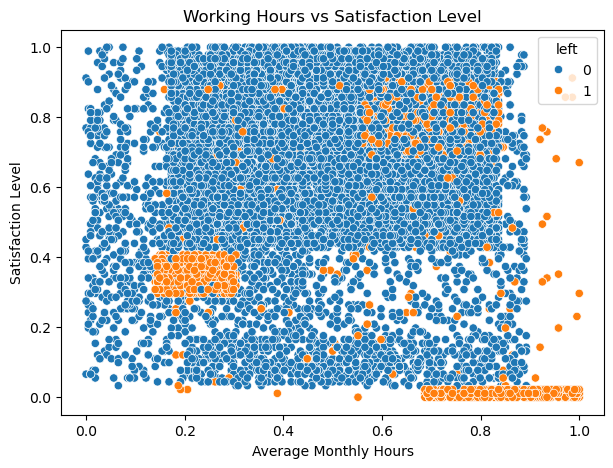

In [37]:
#Analyze how working hours affect satisfaction level (Scatter Plot).
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='avgMonthlyHours',
    y='satisfactoryLevel',
    hue='left',
    data=dataset
)

plt.title("Working Hours vs Satisfaction Level")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Satisfaction Level")

plt.show()

In [40]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [43]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully as scaler.pkl")

Scaler saved successfully as scaler.pkl
